In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

## connection and upload data from checker

In [3]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [4]:
checker = pd.read_sql(
    '''
SELECT timestamp AS date
FROM checker
WHERE uid LIKE 'user_%'
''', conn, parse_dates='date'
)
checker

,date
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370
...,...
3202,2020-05-21 20:19:06.872761
3203,2020-05-21 20:22:41.785725
3204,2020-05-21 20:22:41.877806
3205,2020-05-21 20:37:00.129678


In [5]:
checker['hour'] = checker.date.dt.hour
checker['type'] = checker.date.apply(lambda x: 'working_day' if x.weekday() < 5 else 'weekend')
checker

,date,hour,type
0,2020-04-17 05:19:02.744528,5,working_day
1,2020-04-17 05:22:35.249331,5,working_day
2,2020-04-17 05:22:45.549397,5,working_day
3,2020-04-17 05:34:14.691200,5,working_day
4,2020-04-17 05:34:24.422370,5,working_day
...,...,...,...
3202,2020-05-21 20:19:06.872761,20,working_day
3203,2020-05-21 20:22:41.785725,20,working_day
3204,2020-05-21 20:22:41.877806,20,working_day
3205,2020-05-21 20:37:00.129678,20,working_day


## grouped data

In [6]:
list_working = checker[checker.type == 'working_day']['hour'].values
len(list_working)


2037

In [14]:
list_weekend = checker[checker.type == 'weekend']['hour'].values
len(list_weekend)

1170

## dras histogram

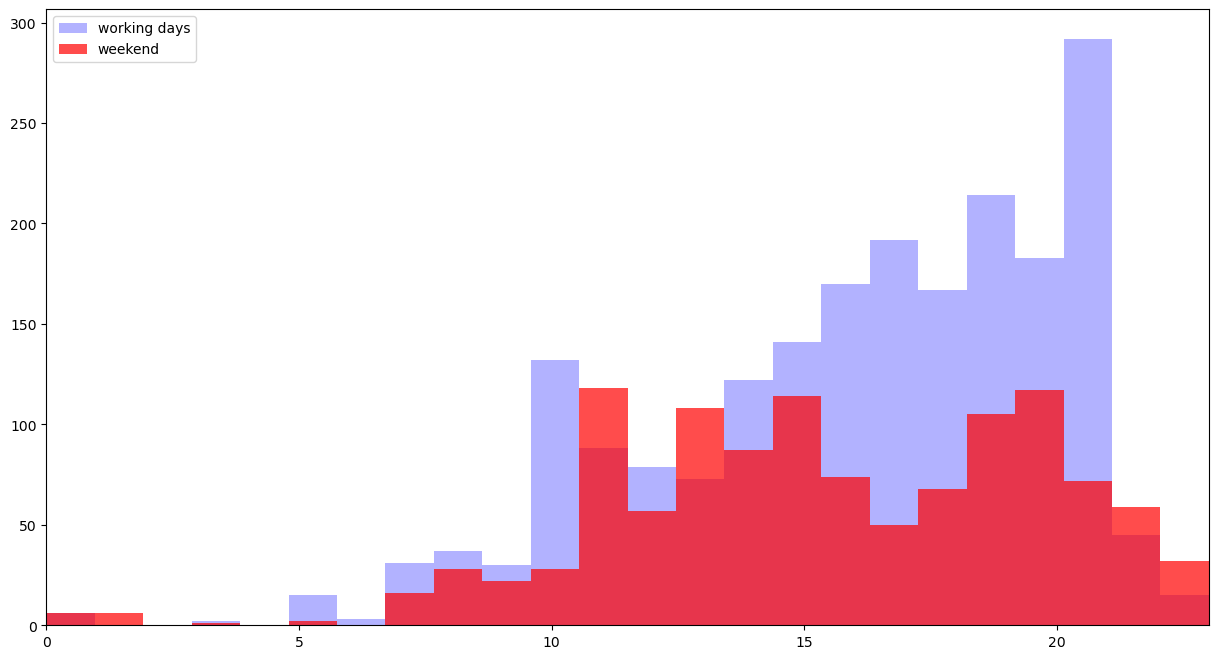

In [8]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.hist(list_working,
        bins = 24,
        label='working days',
        alpha=0.3,
        color='blue')
ax.hist(list_weekend,
        bins = 24,
        label='weekend',
        alpha=0.7,
        color='red')
ax.set_xlim(0,23)
ax.legend(loc='upper left', fontsize='10')
plt.show()

## Are there hours when the total number of commits was higher on weekends than on working days ?

In [9]:
grouped = checker.groupby(['hour', 'type']).count().reset_index()
grouped

,hour,type,date
0,0,weekend,6
1,0,working_day,6
2,1,weekend,6
3,3,weekend,1
4,3,working_day,2
5,5,weekend,2
6,5,working_day,15
7,6,working_day,3
8,7,weekend,16
9,7,working_day,31


In [10]:
pivot_table = pd.pivot(grouped, 
                        values='date',
                        index='hour', 
                        columns='type').fillna(0)
pivot_table

type,weekend,working_day
hour,,
0,6.0,6.0
1,6.0,0.0
3,1.0,2.0
5,2.0,15.0
6,0.0,3.0
7,16.0,31.0
8,28.0,37.0
9,22.0,30.0
10,28.0,132.0


In [11]:
(pivot_table.weekend - pivot_table.working_day).nlargest(n=4)

hour
13    35.0
11    30.0
23    17.0
22    14.0
dtype: float64

## Answer : 13, 11, 23, 22

In [12]:
conn.close()